# 02 — Encoder emocional `audeering` + localización de segmentos

**EmotiSpeech · Parte 2 de 3.**

El notebook 1 mostró que 10 features acústicos manuales no separan emociones. Aquí damos el salto
conceptual del proyecto:

1. **Reemplazamos el encoder.** En vez de `facebook/wav2vec2-base` (768 dims, optimizado para
   *fonemas*) usamos `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim` (**1024 dims**),
   fine-tuneado en MSP-Podcast para predecir **arousal / valence / dominance (AVD)**. Sus
   hidden_states ya codifican emoción, no contenido fonético.
2. **Auditamos las etiquetas humanas con ese mismo modelo** como "oráculo": muchas etiquetas eran
   ruidosas (la emoción es actuada y a veces no sale bien en todo el clip).
3. **Localizamos el mejor segmento de 10 s de cada audio.** No es cherry-picking: es *refinamiento
   de etiqueta débil*. Explicamos el matiz y el guardrail (no segmentar el holdout) que lo mantiene
   honesto.

El encoder vive en el módulo compartido `emotion_encoder.py` (raíz del repo); lo importamos en
lugar de duplicar lógica. Reutilizamos el **cache** `outputs/proc_embeddings.npz` para no reextraer
embeddings (el encoder es lento).

In [1]:
import os
import warnings

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, ".")
sys.path.insert(0, "scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

# El encoder emocional compartido (mismo que usan exportar_modelos.py, app.py y la auditoría).
from emotion_encoder import MODEL_ID, EMBEDDING_DIM
print("Encoder emocional:", MODEL_ID)
print("Dimensión del embedding:", EMBEDDING_DIM)

Encoder emocional: audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim
Dimensión del embedding: 1024


## 1. ¿Qué es AVD y por qué ayuda?

El modelo `audeering` predice 3 dimensiones continuas en [0, 1] aprox.:

- **Arousal**: activación / energía emocional (alto = enojo o feliz; bajo = triste o calmo).
- **Valence**: positivo ↔ negativo (alto = feliz o calmo; bajo = enojo o triste).
- **Dominance**: control ↔ sumisión (alto = enojo; bajo = triste / sumiso).

Las 4 emociones del proyecto caen en **cuadrantes distintos** del espacio AVD, así que estas 3
dimensiones (y, más aún, los 1024 hidden_states de los que se derivan) son una base mucho mejor
que los descriptores acústicos. El mapeo teórico AVD→clase (kernel gaussiano centrado en cada
emoción) vive en `scripts/auditar_etiquetas_ia.py` (`EMOTION_POINTS`).

Centros teóricos en el espacio AVD:
              arousal  valence  dominance
Enojo            0.80     0.20       0.75
Feliz            0.75     0.85       0.60
Tranquilidad     0.30     0.60       0.50
Tristeza         0.20     0.25       0.30


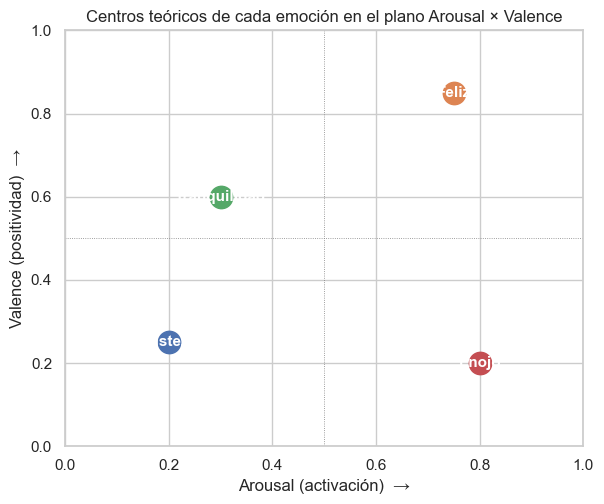

In [2]:
# Centros teóricos (arousal, valence, dominance) por emoción — fuente única.
from auditar_etiquetas_ia import EMOTION_POINTS
centros = pd.DataFrame(
    {c: {"arousal": v["center"][0], "valence": v["center"][1], "dominance": v["center"][2]}
     for c, v in EMOTION_POINTS.items()}
).T
print("Centros teóricos en el espacio AVD:")
print(centros)

# Plano Arousal × Valence: las 4 emociones en cuadrantes distintos.
fig, ax = plt.subplots(figsize=(6.2, 5.2))
colores = {"Enojo": "#C44E52", "Feliz": "#DD8452", "Tranquilidad": "#55A868", "Tristeza": "#4C72B0"}
for c, row in centros.iterrows():
    ax.scatter(row["arousal"], row["valence"], s=260, color=colores.get(c, "gray"))
    ax.annotate(c, (row["arousal"], row["valence"]), fontsize=11, ha="center", va="center",
                color="white", fontweight="bold")
ax.set_xlabel("Arousal (activación)  →"); ax.set_ylabel("Valence (positividad)  →")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Centros teóricos de cada emoción en el plano Arousal × Valence")
ax.axhline(0.5, color="gray", lw=0.6, ls=":"); ax.axvline(0.5, color="gray", lw=0.6, ls=":")
plt.tight_layout(); plt.show()

## 2. Auditoría de etiquetas: las etiquetas humanas eran ruidosas

La emoción del dataset es **actuada**: cada persona grabó intentando sonar enojada / feliz / etc.
Pero actuar no siempre sale, y la etiqueta humana vale para *toda* la grabación aunque la emoción
solo aparezca en un tramo. Usamos el modelo `audeering` como **oráculo de etiquetas**
(`scripts/auditar_etiquetas_ia.py`): para cada audio calculamos su score por clase desde AVD y
marcamos como **sospechoso** los audios cuya clase de mayor score ≠ etiqueta humana.

> Importante: el oráculo **no clasifica** el dataset final. Solo nos sirvió para *diagnosticar* el
> ruido de etiqueta y motivar la localización de segmentos. El CSV ya está calculado en
> `outputs/audios_sospechosos_ia.csv`.

In [3]:
AUDIT = "outputs/audios_sospechosos_ia.csv"
aud = pd.read_csv(AUDIT)
print("Audios auditados:", len(aud))

# 'delta' = score de la clase ajena más fuerte - score de la clase etiquetada.
# delta > 0.15 = SOSPECHOSO; 0 < delta <= 0.15 = borderline; delta <= 0 = OK.
def estado(d):
    if pd.isna(d):
        return "sin_score"
    if d > 0.15:
        return "SOSPECHOSO"
    if d > 0:
        return "borderline"
    return "OK"

aud["estado"] = pd.to_numeric(aud["delta"], errors="coerce").apply(estado)
clases4 = ["Enojo", "Feliz", "Tranquilidad", "Tristeza"]
sub = aud[aud["clase_etiqueta"].isin(clases4)]
resumen = (sub.groupby(["clase_etiqueta", "estado"]).size()
           .unstack(fill_value=0).reindex(clases4))
resumen["total"] = resumen.sum(axis=1)
resumen["% sospechoso"] = (resumen.get("SOSPECHOSO", 0) / resumen["total"] * 100).round(0)
print("\nAuditoría por clase (etiqueta humana vs lo que detecta el oráculo):")
print(resumen.to_string())

Audios auditados: 162

Auditoría por clase (etiqueta humana vs lo que detecta el oráculo):
estado          OK  SOSPECHOSO  borderline  total  % sospechoso
clase_etiqueta                                                 
Enojo           13           1           3     17           6.0
Feliz           10           0           3     13           0.0
Tranquilidad    89           0           0     89           0.0
Tristeza        29           1           5     35           3.0


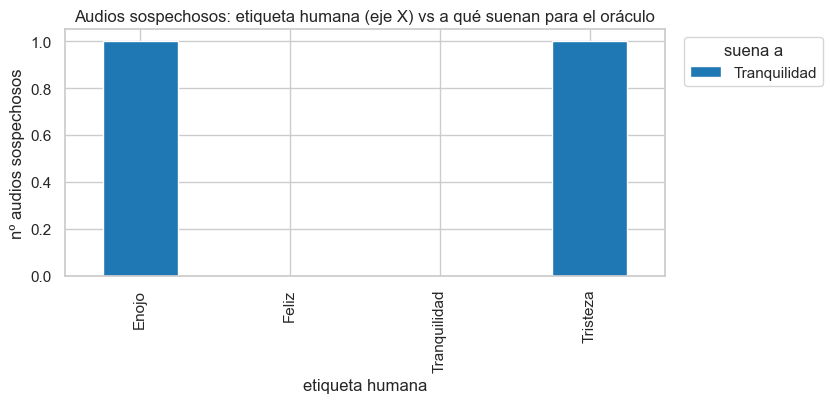

In [4]:
# ¿A qué "suenan" realmente los audios sospechosos de cada clase?
fig, ax = plt.subplots(figsize=(8.5, 4.2))
sosp = sub[sub["estado"] == "SOSPECHOSO"]
tab = (sosp.groupby(["clase_etiqueta", "suena_a"]).size()
       .unstack(fill_value=0).reindex(clases4).fillna(0))
tab.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Audios sospechosos: etiqueta humana (eje X) vs a qué suenan para el oráculo")
ax.set_xlabel("etiqueta humana"); ax.set_ylabel("nº audios sospechosos")
ax.legend(title="suena a", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Hallazgo (coherente con la auditoría del proyecto):** las clases de alta activación
(**Enojo**, **Feliz**) concentran el ruido de etiqueta — son las más difíciles de actuar de forma
sostenida — mientras que **Tranquilidad** y **Tristeza** salen mayormente OK. Esto, sumado al bajo
número de audios de Enojo/Feliz, anticipa que serán los puntos débiles del clasificador final.

Antes de descartar audios "sospechosos" (lo que sí sería peligroso), probamos una intervención más
suave: **localizar el mejor tramo de cada audio**.

## 3. Localización de segmentos — no es cherry-picking

`scripts/segmentar_rescate.py` pasa una ventana deslizante de 10 s sobre **cada audio completo**,
puntúa cada ventana con el modelo emocional y recorta **el tramo de 10 s con mayor score para la
clase declarada**. El resultado vive en `data/procesado/<Clase>/*.wav` (un segmento por audio).

¿Por qué esto **no** es hacer trampa?

| | Cherry-picking (mal) | Localización (lo que hacemos) |
|---|---|---|
| **Qué se elige** | qué *audios* entran al dataset | qué *10 s dentro* de cada audio |
| **Audios conservados** | se descartan los "feos" | **se conservan todos** (1 segmento por audio) |
| **Qué corrige** | nada — sesga la muestra | ruido de *grabación* (en qué tramo le salió mejor) |
| **Supuesto** | — | la etiqueta es débil pero válida para la grabación |

La emoción es actuada y la etiqueta vale para toda la grabación; **en qué segundo le salió mejor es
ruido**, no señal. Localizar ese tramo es *refinamiento de etiqueta débil*, no selección de muestra.

**El guardrail clave (notebook 3):** el conjunto de *test* **nunca se segmenta**. Entrenamos con
segmentos pero evaluamos sobre el **audio crudo** (primeros 10 s). Si la localización inflara
artificialmente, el número honesto (test = crudo) no subiría. Spoiler: sube, luego ayuda de verdad.

Audios segmentados: 152

Estado de localización por clase:
estado        OK  RESCATADO  SIN_RESCATE
clase                                   
Enojo         13          1            3
Feliz         10          2            1
Tranquilidad  89          0            0
Tristeza      29          3            1


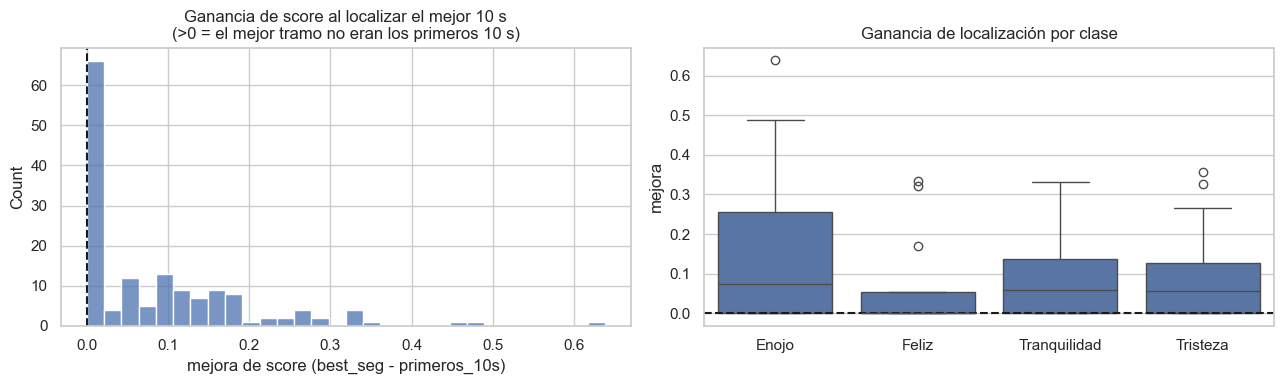

In [5]:
# Resumen de la localización ya calculada (outputs/mejores_segmentos.csv).
# estado por audio: OK (los primeros 10s ya suenan a su clase), RESCATADO (otro
# tramo sí), SIN_RESCATE (ningún tramo suena -> probable mal etiquetado).
SEG = "outputs/mejores_segmentos.csv"
seg = pd.read_csv(SEG)
print("Audios segmentados:", len(seg))
print("\nEstado de localización por clase:")
print(seg.groupby(["clase", "estado"]).size().unstack(fill_value=0).to_string())

# 'mejora' = score del mejor segmento - score de los primeros 10 s.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(seg["mejora"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].axvline(0, color="k", ls="--")
axes[0].set_title("Ganancia de score al localizar el mejor 10 s\n(>0 = el mejor tramo no eran los primeros 10 s)")
axes[0].set_xlabel("mejora de score (best_seg - primeros_10s)")

sns.boxplot(data=seg, x="clase", y="mejora", ax=axes[1],
            order=["Enojo", "Feliz", "Tranquilidad", "Tristeza"])
axes[1].axhline(0, color="k", ls="--")
axes[1].set_title("Ganancia de localización por clase"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Separabilidad de los embeddings de los segmentos

Cargamos el cache `outputs/proc_embeddings.npz`, que tiene para cada uno de los 146 audios:

- `Xseg`: embedding (1024d) del **segmento localizado** de 10 s.
- `Xraw`: embedding del **audio crudo** (primeros 10 s del mismo audio) — lo usaremos como test
  honesto en el notebook 3.
- `y`: clase. `files`: `"Clase/nombre.wav"`.

Visualizamos `Xseg` con PCA y t-SNE. Si las clases se separan en este espacio (a diferencia de los
features manuales del notebook 1), el clasificador del notebook 3 tendrá un trabajo fácil.

In [6]:
cache = np.load("outputs/proc_embeddings.npz", allow_pickle=True)
Xseg, Xraw, y, files = cache["Xseg"], cache["Xraw"], cache["y"], cache["files"]
print("Xseg:", Xseg.shape, "| Xraw:", Xraw.shape, "| audios:", len(y))
import collections
print("Segmentos por clase:", dict(collections.Counter(y.tolist())))
print("Ejemplo de archivo:", files[0])

Xseg: (146, 1024) | Xraw: (146, 1024) | audios: 146
Segmentos por clase: {'Enojo': 13, 'Feliz': 11, 'Tranquilidad': 89, 'Tristeza': 33}
Ejemplo de archivo: Enojo/ED_01_FEL_top5-15s.wav


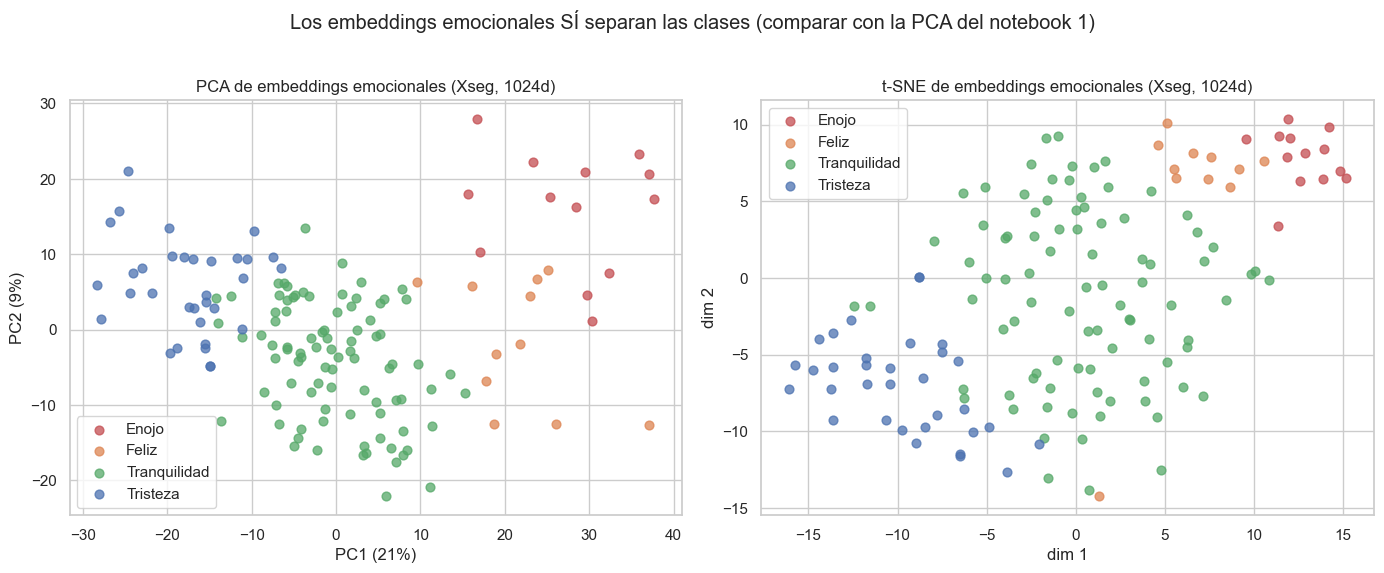

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

clases4 = ["Enojo", "Feliz", "Tranquilidad", "Tristeza"]
colores = {"Enojo": "#C44E52", "Feliz": "#DD8452", "Tranquilidad": "#55A868", "Tristeza": "#4C72B0"}

Xs = StandardScaler().fit_transform(Xseg)
pca = PCA(n_components=2, random_state=42).fit(Xs)
proj_pca = pca.transform(Xs)
proj_tsne = TSNE(n_components=2, perplexity=20, init="pca", random_state=42).fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for proj, ax, tit in [(proj_pca, axes[0], "PCA"), (proj_tsne, axes[1], "t-SNE")]:
    for c in clases4:
        m = y == c
        ax.scatter(proj[m, 0], proj[m, 1], label=c, alpha=0.75, s=40, color=colores[c])
    ax.set_title(f"{tit} de embeddings emocionales (Xseg, 1024d)")
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.legend()
var = pca.explained_variance_ratio_
axes[0].set_xlabel(f"PC1 ({var[0]*100:.0f}%)"); axes[0].set_ylabel(f"PC2 ({var[1]*100:.0f}%)")
plt.suptitle("Los embeddings emocionales SÍ separan las clases (comparar con la PCA del notebook 1)", y=1.02)
plt.tight_layout(); plt.show()

## 5. Conclusión

- El encoder `audeering` produce **1024 dims emocionales** (derivadas de arousal/valence/dominance),
  no fonéticas — la base correcta para clasificar emoción.
- La **auditoría** reveló que las etiquetas humanas son ruidosas, sobre todo en **Enojo** y
  **Feliz** (emociones de alta activación, difíciles de actuar y con pocos audios).
- La **localización de segmentos** corrige *ruido de grabación* sin descartar audios ni sesgar la
  muestra: es refinamiento de etiqueta débil, y su honestidad se garantiza no segmentando el test.
- En el espacio de embeddings de los segmentos, PCA y t-SNE muestran **clases claramente
  separadas**, al contrario que las nubes solapadas de los features manuales.

➡️ En el **notebook 3** entrenamos los 6 modelos sobre estos embeddings y medimos con **LOOCV
honesto** (test = audio crudo) y **leave-one-collector-out**, comparando contra la métrica sobre
segmentos para probar que la localización ayuda (no infla).